# DSCI 631 Project Proposal

Group 2\
Leland Weeks\
lhw22@drexel.edu\
April 26, 2026

### Board Game Ratings Using BoardGameGeek Data

Questions I hope to answer:
1. What games are over and underated?
    - Target: Classification of the gap between ownership vs Average Rating
    - Reason: Help boardgame lovers find enjoyable games
2. What features make a boardgame enjoyable?
    - Target: Predict Average Rating based on games features
    - Reason: Informs games designers and publishers on what games to make
3. What level of complexity makes a game successful in a genre?
    - Target: Predict Game Rating based on game complexity grouped by genre
    - Reason: Deep dive into previous question because genres have different target demographics


## 1. Dataset Description

**Source:** https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek

**Description (from Kaggle):** "Feature-rich multi-table dataset full of interesting information about Board Games which can be used for tasks such as exploratory EDA, predictive modeling, or recommender systems."

**Detailed Description:** 
BoardGameGeek is the defacto authoritative database for boardgames and card games, crowdsourced by its large active community, who have contributed player ratings, game assessments, and metadata across over 22,000 published games. The data lends itself to geninue signals because the data is from actual players, not marketing by the publisher. 

### Files

| File | Description | Usage | 
|------|-------------|-------|
| `games.csv` | Core file containing all primary features and target variables | Needed to answer all 3 questions
| `mechanics.csv` | Game mechanics like `Dice Rolling`, `Cooperative Game`) | Feature set for Q2 |
| `themes.csv` | Genres like `Fantasy`, `Science Fiction`, `Horror` | Feature set for Q2 |
| `subcategories.csv` | Game categories like `Card Game`, `Puzzle` | Feature set for Q2 |

### Key Features

- **Numeric features:** `GameWeight`, `MinPlayers`, `MaxPlayers`, `MfgPlayTime`, `NumOwned`, `NumWant`, `NumExpansions`, `YearPublished`, etc.
- **Binary features:** `IsReimplementation`, `Kickstarted`, subcategories `Strategy`, `Thematic`, etc.

In [438]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# this code to download the dataset taken from provided kaggle URL
path = kagglehub.dataset_download("threnjen/board-games-database-from-boardgamegeek")
print("Path to dataset files:", path)

# load the data into dataframes
df_games = pd.read_csv(path + '/games.csv')
df_mecha = pd.read_csv(path + '/mechanics.csv')
df_themes = pd.read_csv(path + '/themes.csv')
df_subcat = pd.read_csv(path + '/subcategories.csv')

print('Data loaded: games.csv, mechanics.csv, themes.csv, subcategories.csv')

Path to dataset files: /Users/lelandweeks/.cache/kagglehub/datasets/threnjen/board-games-database-from-boardgamegeek/versions/4
Data loaded: games.csv, mechanics.csv, themes.csv, subcategories.csv


## 2. Exploratory Data Analysis (EDA)

My EDA is focused on ensuring that the dataset I chose has the correct data and signals to answer the three questions I asked in the heading of this document:
1. What games are over and underated?
2. What features make a boardgame enjoyable?
3. What level of complexity makes a game successful in a genre?

In order to answer those questions, I need:
1. `NumOwned` and `AvgRating` to figure out if people are (1) dissapointed in games after they buy them or (2) if only a relatively small number of people have bought a game and have rated it very highly. The gap between the two will inform the threshold for classificaiton.
2. Model various game features `MinPlayers`, `MaxPlayers`, `Negotiation`, `Dexterity`, `Kickstarted`, `ComMinPlaytime` etc to predict `AvgRating`, the strongest signal for enjoyment. 
3. Assess whether `GameWeight` and `AvgRating` provide meaningful signal within each genre `Strategy`, `Family`, `Party`, etc to determine complexity-to-rating relationship across games.

Analysis of EDA below. 

### 2.1 Dataset Shape & Types


In [441]:
print('Games Shape:', df_games.shape)
print('Mechanics Shape:', df_mecha.shape)
print('Themes Shape:', df_themes.shape)
print('Categories Shape:', df_subcat.shape)
print()

print('Games dtypes head:')
print(df_games.dtypes.head())
print()

print('Games Table Description:')
df_temp = df_games[['GameWeight', 'AvgRating', 'NumUserRatings', 'NumOwned', 'NumWant', 
                    'ComMinPlaytime', 'Cat:Strategy', 'Cat:Family']].describe()
display(df_temp.round({'GameWeight': 1, 'AvgRating': 2, 'NumUserRatings': 0, 'NumOwned': 0, 'NumWant': 0,
                       'ComMinPlaytime': 0, 'Cat:Strategy': 2, 'Cat:Family': 2}))
print()

print('Mechanics, Themes, Categories Tables Descriptions:')
df_temp = pd.merge(df_games, df_mecha, on='BGGId')
df_temp = pd.merge(df_temp, df_themes, on='BGGId')
df_temp = pd.merge(df_temp, df_subcat, on='BGGId')
df_temp = df_temp[['Dice Rolling', 'Cooperative Game', 'Fantasy', 'Science Fiction',
                  'Card Game', 'Puzzle']].describe()
display(df_temp.round({'Dice Rolling': 0, 'Cooperative Game': 0, 'Fantasy': 0, 'Science Fiction': 0,
                  'Card Game': 0, 'Puzzle': 0}))

Games Shape: (21925, 48)
Mechanics Shape: (21925, 158)
Themes Shape: (21925, 218)
Categories Shape: (21925, 11)

Games dtypes head:
BGGId              int64
Name              object
Description       object
YearPublished      int64
GameWeight       float64
dtype: object

Games Table Description:


,GameWeight,AvgRating,NumUserRatings,NumOwned,NumWant,ComMinPlaytime,Cat:Strategy,Cat:Family
count,21925.0,21925.00,21925.0,21925.0,21925.0,21925.0,21925.00,21925.00
mean,2.0,6.42,862.0,1468.0,42.0,64.0,0.11,0.11
std,0.8,0.93,3639.0,5294.0,117.0,444.0,0.31,0.31
min,0.0,1.04,30.0,0.0,0.0,0.0,0.00,0.00
25%,1.3,5.84,56.0,150.0,3.0,20.0,0.00,0.00
50%,2.0,6.45,123.0,320.0,9.0,30.0,0.00,0.00
75%,2.5,7.05,395.0,899.0,28.0,60.0,0.00,0.00
max,5.0,9.91,108101.0,166497.0,2031.0,60000.0,1.00,1.00



Mechanics, Themes, Categories Tables Descriptions:


,Dice Rolling,Cooperative Game,Fantasy,Science Fiction,Card Game,Puzzle
count,21925.0,21925.0,21925.0,21925.0,21925.0,21925.0
mean,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0
75%,1.0,0.0,0.0,0.0,1.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


### 2.2 Missing Values


In [443]:
nulls_games = df_games.isnull().sum()
nulls_mecha = df_mecha.isnull().sum()
nulls_themes = df_themes.isnull().sum()
nulls_subcat = df_subcat.isnull().sum()

# is the size of the dataset representitive of 
print("Nulls in games:")
print(nulls_games[nulls_games > 0] if nulls_games.any() else "No nulls found")
print()

print("Nulls in mechanics:")
print(nulls_mecha[nulls_mecha > 0] if nulls_mecha.any() else "No nulls found")
print()

print("Nulls in themes:")
print(nulls_themes[nulls_themes > 0] if nulls_themes.any() else "No nulls found")
print()

print("Nulls in categories:")
print(nulls_subcat[nulls_subcat > 0] if nulls_subcat.any() else "No nulls found")
print()

Nulls in games:
Description         1
ComAgeRec        5530
LanguageEase     5891
Family          15262
ImagePath          17
dtype: int64

Nulls in mechanics:
No nulls found

Nulls in themes:
No nulls found

Nulls in categories:
No nulls found



### 2.3 Target Variable Distribution

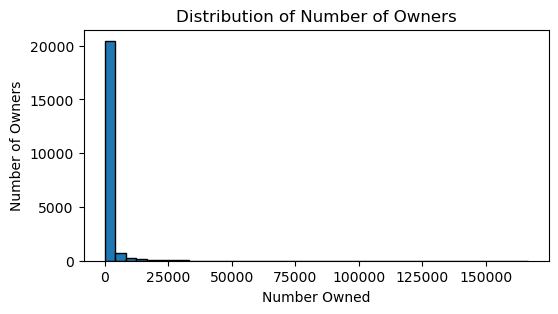

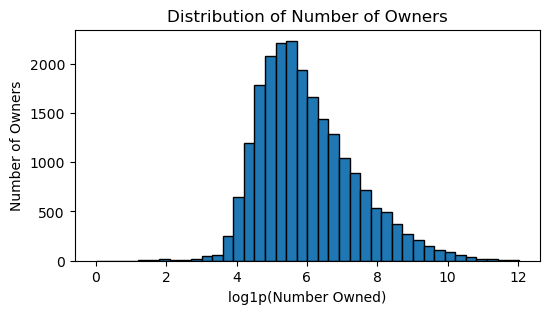

In [445]:
# Q1
# What games are over and underated?
# Target: Classification of the gap between ownership vs Average Rating

# drop the rows that don't have data 
data1 = df_games['NumOwned'].dropna()
data2 = np.log1p(df_games['NumOwned'])

# understand the distribution to check whether this is a good canidate for linear regression
plt.figure(figsize=(6, 3))
plt.hist(data1, bins=40, edgecolor='black')
plt.title('Distribution of Number of Owners')
plt.xlabel('Number Owned')
plt.ylabel('Number of Owners')
plt.show()
plt.close()

# the previous hist had a huge tail so take the log for more meaning
plt.figure(figsize=(6, 3))
plt.hist(data2, bins=40, edgecolor='black')
plt.title('Distribution of Number of Owners')
plt.xlabel('log1p(Number Owned)')
plt.ylabel('Number of Owners')
plt.show()
plt.close()

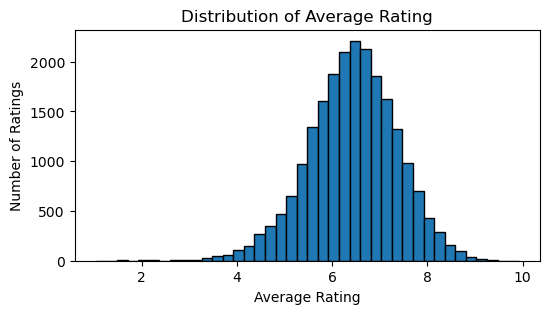

In [446]:
# Q2 (Q1 also uses AvgRating)
# What features make a boardgame enjoyable?
# Target: Predict Average Rating based on games features

# drop the rows that don't have data
data3 = df_games['AvgRating'].dropna()

# understand the distribution to check whether this is a good canidate for linear regression
plt.figure(figsize=(6, 3))
plt.hist(data3, bins=40, edgecolor='black')
plt.title('Distribution of Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Number of Ratings')
plt.show()
plt.close()

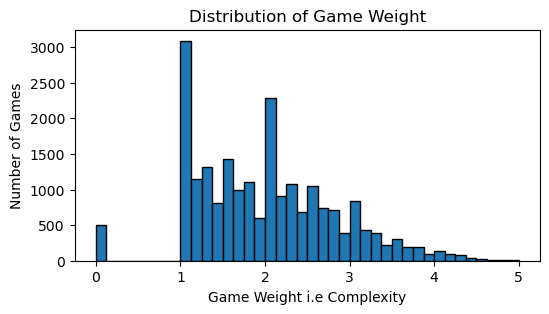

In [447]:
# Q3
# What level of complexity makes a game successful in a genre?
# Target: Predict Game Weight based on game complexity grouped by genre

# drop the rows that don't have data
data4 = df_games['GameWeight'].dropna()

# understand the distribution to check whether this is a good canidate for linear regression
plt.figure(figsize=(6, 3))
plt.hist(data4, bins=40, edgecolor='black')
plt.title('Distribution of Game Weight')
plt.xlabel('Game Weight i.e Complexity')
plt.ylabel('Number of Games')
plt.show()
plt.close()

### 2.4 Feature Distributions & Correlations


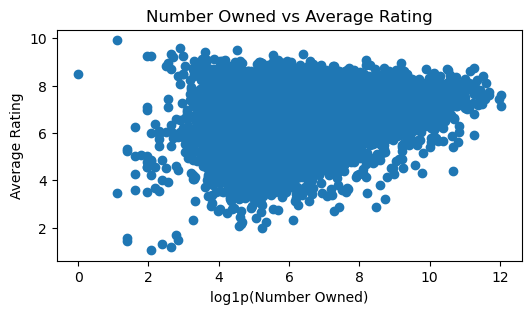

In [449]:
# Q1
# What games are over and underated?
# Target: Classification of the gap between ownership vs Average Rating

x = np.log1p(df_games['NumOwned'])
y = df_games['AvgRating']

plt.figure(figsize=(6, 3))
plt.scatter(x, y)
plt.title("Number Owned vs Average Rating")
plt.xlabel("log1p(Number Owned)")
plt.ylabel("Average Rating")
plt.show()
plt.close()

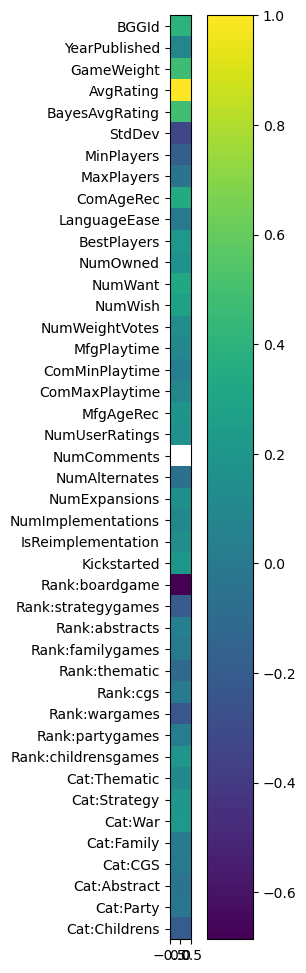

In [451]:
# Q2
# What features make a boardgame enjoyable?
# Target: Predict Average Rating based on games features

# correlation determine which features are relevant to enjoyability
corrs = df_games.select_dtypes('number').corr()[['AvgRating']]

plt.figure(figsize=(4, 12))
plt.imshow(corrs)
plt.yticks(range(len(corrs)), corrs.index)
plt.colorbar()
plt.show()
plt.close()

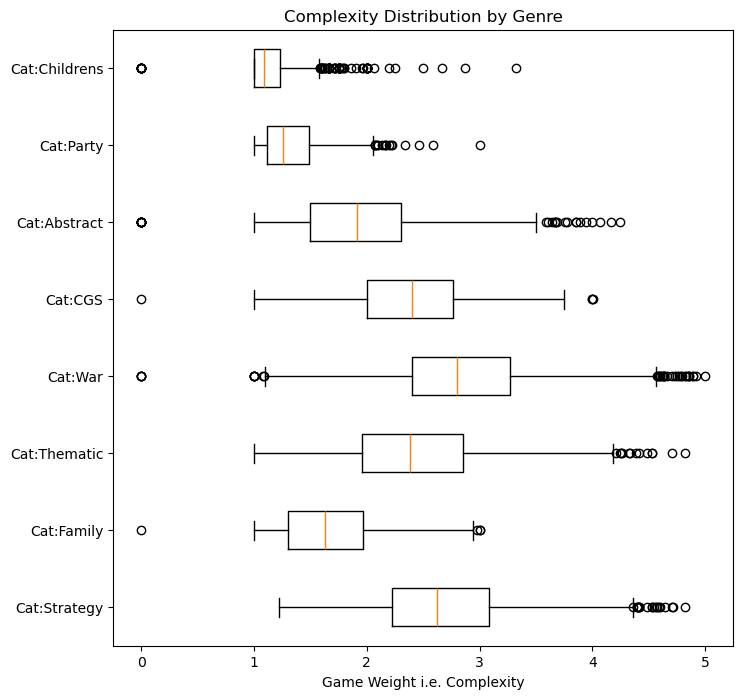

In [453]:
# Q3
# What level of complexity makes a game successful in a genre?
# Target: Predict Game Weight based on game complexity grouped by genre

# create a list of Weight values for each genre
labels = ['Cat:Strategy', 'Cat:Family', 'Cat:Thematic', 'Cat:War', 
          'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens']
data5 = []
for label in labels:
    data5.append(df_games[df_games[label] == 1]['GameWeight'])

plt.figure(figsize=(8,8))
plt.boxplot(data5, tick_labels=labels, vert=False)
plt.xlabel('Game Weight i.e. Complexity')
plt.title('Complexity Distribution by Genre')
plt.show()

### 2.5 Key Observations

* What games are over and underated?
    * `NumOwned` skews to the right, most games are not popular
    * Needed to apply log to normalize data
    * `AvgRating` has a normal distribution, suitable for linear regression
    * Scatter plot shows neither strong positive or weak relationship
* What features make a boardgame enjoyable?
    * `AvgRating` has a normal distribution, good for regression models
    * The correlation heatmap shows which features are correlated
* What level of complexity makes a game successful in a genre?
    * `GameWeight` i.e. complexity distribution shows shows variation
    * Boxplot by genre shows different genres have different complexity ranges

## 3. Proposed Algorithms

The algorithms I plan to target are focused on ensuring that I can gain insight, and hopefully answer, the three questions I asked in the heading of this document:

1. What games are over and underated?
2. What features make a boardgame enjoyable?
3. What level of complexity makes a game successful in a genre?

In order to answer those questions, I currently plan to use these algorithms (may change):

1. Logistic Regression
    - Target: Binary classification high ownership + low rating = disappointed, low ownership + high rating = hidden gem
    - Features: `NumOwned`, `AvgRating`
2. Linear Regression for baseline and Random Forest regressor
    - Target: `AvgRating` 
    - Features: `MinPlayers`, `MaxPlayers`, `Negotiation`, `Dexterity`, `Kickstarted`, `ComMinPlaytime` etc and more from mechanics.csv and themes.csv
3. Gradient Boosting (XGBoost)
    - Target: `AvgRating`
    - Features: `GameWeight` and genres `Strategy`, `Family`, `Party` etc. 